## Python

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import math
import seaborn as sns
import os
# %config IPCompleter.greedy=True
%load_ext autoreload
%autoreload 2

sc.settings.verbosity = 0
sc.logging.print_header()
sns.set_context("paper")

scanpy==1.9.2 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 louvain==0.8.0 pynndescent==0.5.8


In [ ]:
all_mods = pd.read_csv("MPs_malignant.tsv", sep="\t")
all_mods

,MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
0,DIAPH3,CA10,SPARCL1,FTL,BCAS1,VEGFA,GAP43,DNAH6,CD44,HSPH1,SLIT1,KCNH7,CHI3L1
1,RRM2,MMP16,CLU,FTH1,SIRT2,HILPDA,CAMK2D,MAP3K19,ACTN1,HSPE1,CHD7,SRRM4,GALNT15
2,TOP2A,PCDH15,DCLK1,EEF1A1,PKP4,SLC6A6,ITGA3,ARMC3,ELL2,USPL1,EGFR,STMN2,NNMT
3,CENPF,LHFPL3,AQP4,TMSB10,MBP,FAM162A,ADAMTS9,CFAP43,GAP43,CHORDC1,GLCCI1,ELAVL4,ABCA8
4,ASPM,NXPH1,EEPD1,GAPDH,BMPER,NDRG1,HIVEP3,DNAH9,HRH1,HSPD1,GRIK2,MYT1L,ANXA1
5,KNL1,SEZ6L,KCNN3,MIF,CDK18,PDK1,EMP1,C6ORF118,LPAR1,DNAJB1,HES6,NYAP2,C3
6,TPX2,DSCAM,ANOS1,TMSB4X,SHROOM4,INSIG2,GALR1,VWA3A,NAMPT,HSP90AA1,NKD1,RIT2,CP
7,BRIP1,PDGFRA,SLC4A4,B2M,ST18,SLC2A1,RASSF8,ZBBX,CLIC4,HSP90AB1,PAK3,RND3,MGST1
8,KIF14,FGF12,DAAM2,PTMA,MYRF,GBE1,RGS17,SPATA17,OSMR,HSPA1A,SEZ6L,CELF4,SPARCL1
9,NUSAP1,OPCML,APOE,ATP5F1E,PPP1R16B,AKAP12,SPOCD1,ADGB,SAMD4A,HSPA1B,BEST3,CNTNAP5,APOE


## Get GO terms for each module

In [ ]:
from gprofiler import GProfiler
def query_genes( genes, p_thresh=0.05):
    gp = GProfiler( return_dataframe=True)
    query_df = gp.profile( organism='hsapiens', query=genes, user_threshold=p_thresh)
    ####################################################
    # only want moleuclar function and bio processes returned
    query_df = query_df[np.in1d( query_df['source'].values, ['GO:MF','GO:BP'])]
    ####################################################
    # only want less general GOs
#     parent_mk = np.array( [len( ii)>=parent_th for ii in query_df['parents'].values])
    return( query_df) #.loc[parent_mk])

In [ ]:
gos = {}
tfs = {}
pvs = {}
inter = {}
parents = {}

for mp in all_mods:
    range_genes = all_mods[mp]
    q_df = query_genes( range_genes.tolist(), 
                       # p_thresh=0.999
                      )
    gos[str(mp)] = q_df["name"].values
    pvs[str(mp)] = q_df["p_value"].values
    inter[str(mp)] = q_df["intersection_size"].values
    parents[str(mp)] = [len(ii) for ii in q_df['parents']]
gos

{'MP_1': array(['chromosome segregation', 'cell cycle', 'cell cycle process',
        'nuclear division', 'organelle fission',
        'nuclear chromosome segregation', 'mitotic cell cycle',
        'chromosome organization', 'mitotic cell cycle process',
        'mitotic nuclear division', 'sister chromatid segregation',
        'mitotic sister chromatid segregation',
        'regulation of cell cycle process', 'cell division',
        'regulation of cell cycle', 'organelle organization',
        'regulation of mitotic cell cycle',
        'regulation of cell cycle phase transition',
        'cell cycle phase transition', 'meiotic cell cycle',
        'regulation of chromosome segregation', 'microtubule binding',
        'positive regulation of cell cycle process',
        'cell cycle checkpoint signaling',
        'positive regulation of cell cycle', 'tubulin binding',
        'regulation of mitotic cell cycle phase transition',
        'negative regulation of cell cycle phase transi

In [ ]:
# sort by parent level of go term
def get_lvl_gos( lvl_th, go_terms=gos, p_values=pvs, intersect=inter, parents=parents):
    lvl_gos = {}
    lvl_pvs = {}
    lvl_int = {}
    for key_itr in go_terms.keys():
        lvl_gos[key_itr] = [go for go, par in zip( go_terms[key_itr],  parents[key_itr]) if par==lvl_th]
        lvl_pvs[key_itr] = [pv for pv, par in zip( p_values[key_itr],  parents[key_itr]) if par==lvl_th]
        lvl_int[key_itr] = [te for te, par in zip( intersect[key_itr], parents[key_itr]) if par==lvl_th]
    return( lvl_gos, lvl_pvs, lvl_int)

In [ ]:
lvl1_gos, lvl1_pvs, lvl1_int = get_lvl_gos( 1)
lvl2_gos, lvl2_pvs, lvl2_int = get_lvl_gos( 2)
lvl3_gos, lvl3_pvs, lvl3_int = get_lvl_gos( 3)
lvl4_gos, lvl4_pvs, lvl4_int = get_lvl_gos( 4)

In [ ]:
get_lvl_gos( 1)

({'MP_1': ['chromosome segregation',
   'cell cycle',
   'nuclear division',
   'organelle fission',
   'nuclear chromosome segregation',
   'mitotic cell cycle',
   'chromosome organization',
   'cell division',
   'organelle organization',
   'cell cycle phase transition',
   'microtubule binding',
   'tubulin binding',
   'microtubule-based process',
   'chromosome localization',
   'ATP-dependent activity',
   'DNA metabolic process',
   'DNA damage response',
   'adenyl nucleotide binding',
   'spindle assembly checkpoint signaling',
   'kinetochore organization',
   'meiosis I cell cycle process',
   'spindle checkpoint signaling',
   'cytoskeletal motor activity',
   'cytoskeletal protein binding',
   'sexual reproduction',
   'purine nucleotide binding',
   'non-membrane-bounded organelle assembly',
   'nucleoside phosphate binding',
   'chromosome condensation',
   'cell cycle G2/M phase transition',
   'DNA recombination',
   'carbohydrate derivative binding',
   'organelle l

In [ ]:
get_lvl_gos( 2)

({'MP_1': ['cell cycle process',
   'mitotic cell cycle process',
   'mitotic nuclear division',
   'sister chromatid segregation',
   'regulation of cell cycle process',
   'regulation of cell cycle',
   'regulation of mitotic cell cycle',
   'regulation of cell cycle phase transition',
   'regulation of chromosome segregation',
   'cell cycle checkpoint signaling',
   'mitotic cell cycle phase transition',
   'regulation of nuclear division',
   'metaphase chromosome alignment',
   'regulation of organelle organization',
   'regulation of chromosome separation',
   'regulation of chromosome organization',
   'chromosome separation',
   'microtubule cytoskeleton organization',
   'meiotic nuclear division',
   'regulation of mitotic sister chromatid segregation',
   'DNA repair',
   'microtubule motor activity',
   'ATP binding',
   'microtubule cytoskeleton organization involved in mitosis',
   'adenyl ribonucleotide binding',
   'mitotic spindle checkpoint signaling',
   'metaphase/

In [ ]:
get_lvl_gos( 3)

({'MP_1': ['mitotic sister chromatid segregation',
   'meiotic cell cycle',
   'positive regulation of cell cycle process',
   'positive regulation of cell cycle',
   'regulation of mitotic cell cycle phase transition',
   'negative regulation of cell cycle phase transition',
   'mitotic cell cycle checkpoint signaling',
   'meiotic cell cycle process',
   'negative regulation of cell cycle process',
   'establishment of chromosome localization',
   'negative regulation of cell cycle',
   'regulation of sister chromatid segregation',
   'negative regulation of mitotic cell cycle',
   'mitotic spindle assembly checkpoint signaling',
   'negative regulation of mitotic sister chromatid segregation',
   'regulation of mitotic metaphase/anaphase transition',
   'negative regulation of chromosome separation',
   'negative regulation of metaphase/anaphase transition of cell cycle',
   'negative regulation of chromosome segregation',
   'regulation of metaphase/anaphase transition of cell cycl

In [ ]:
get_lvl_gos( 4)

({'MP_1': ['regulation of mitotic nuclear division',
   'negative regulation of mitotic cell cycle phase transition',
   'negative regulation of sister chromatid segregation',
   'negative regulation of mitotic sister chromatid separation',
   'kinetochore assembly'],
  'MP_2': [],
  'MP_3': ['negative regulation of amyloid-beta formation'],
  'MP_4': ['regulation of protein metabolic process',
   'negative regulation of protein metabolic process',
   'translation'],
  'MP_5': [],
  'MP_6': ['canonical glycolysis',
   'pyridine-containing compound metabolic process'],
  'MP_7': [],
  'MP_8': ['spermatid differentiation',
   'germ cell development',
   'sperm axoneme assembly'],
  'MP_9': [],
  'MP_10': ['regulation of protein metabolic process',
   'positive regulation of cellular biosynthetic process',
   'positive regulation of protein metabolic process',
   'positive regulation of cellular metabolic process',
   'positive regulation of protein catabolic process',
   'positive regula

In [ ]:
# assumes go_dict is already sorted by p-value
def get_n_top_gos( go_dict, pv_dict, in_dict, N):
    top_g_dict = {}
    top_p_dict = {}
    top_i_dict = {}
    for k_itr in go_dict.keys():
        go_itr = go_dict[k_itr]
        pv_itr = pv_dict[k_itr]
        in_itr = in_dict[k_itr]
        top_g_dict[k_itr] = go_itr[:N]
        top_p_dict[k_itr] = pv_itr[:N]
        top_i_dict[k_itr] = in_itr[:N]
    return( top_g_dict, top_p_dict, top_i_dict)

In [ ]:
###################################################################
######### here is where you control level of GO terms
###################################################################
top_gos_dict, top_pvs_dict, top_int_dict = get_n_top_gos( lvl2_gos,lvl2_pvs, lvl2_int, 5)

In [ ]:
# create dataframe to hold p-values for mods and go terms
col_names = []
for vals in top_gos_dict.values():
    col_names = np.append( col_names, vals)
print( col_names.shape)
col_names = np.unique( col_names)
print( col_names.shape)

(59,)
(49,)


In [ ]:
gm_df = pd.DataFrame( [], index=list( top_gos_dict.keys()), columns=col_names, dtype=float)
in_df = pd.DataFrame( [], index=list( top_gos_dict.keys()), columns=col_names, dtype=int)
gm_df.iloc[:,:] = np.log10( 1.0)
in_df.iloc[:,:] = 0

In [ ]:
-np.log10(1.0), -np.log10( 0.05), -np.log10( 0.0000005)

(-0.0, 1.3010299956639813, 6.301029995663981)

In [ ]:
for mod_itr in gos.keys():
    pvs_itr = top_pvs_dict[mod_itr]
    gos_itr = top_gos_dict[mod_itr]
    for p_itr, go_itr in zip( pvs_itr, gos_itr):
        gm_df.loc[mod_itr,go_itr] = -np.log10( p_itr)    
        
for mod_itr in gos.keys():
    in_itr  = top_int_dict[mod_itr]
    gos_itr = top_gos_dict[mod_itr]
    for i_itr, go_itr in zip( in_itr, gos_itr):
        in_df.loc[mod_itr,go_itr] = i_itr

In [ ]:
gm_df.index.values

array(['MP_1', 'MP_2', 'MP_3', 'MP_4', 'MP_5', 'MP_6', 'MP_7', 'MP_8',
       'MP_9', 'MP_10', 'MP_11', 'MP_12', 'MP_13'], dtype=object)

In [ ]:
#######################
ttt = 0.05
th = -np.log10(ttt)
# gm_df[gm_df>=th] = th
#######################

In [ ]:
cmap = sns.color_palette( "ch:start=.2,rot=-.3", n_colors=1000)

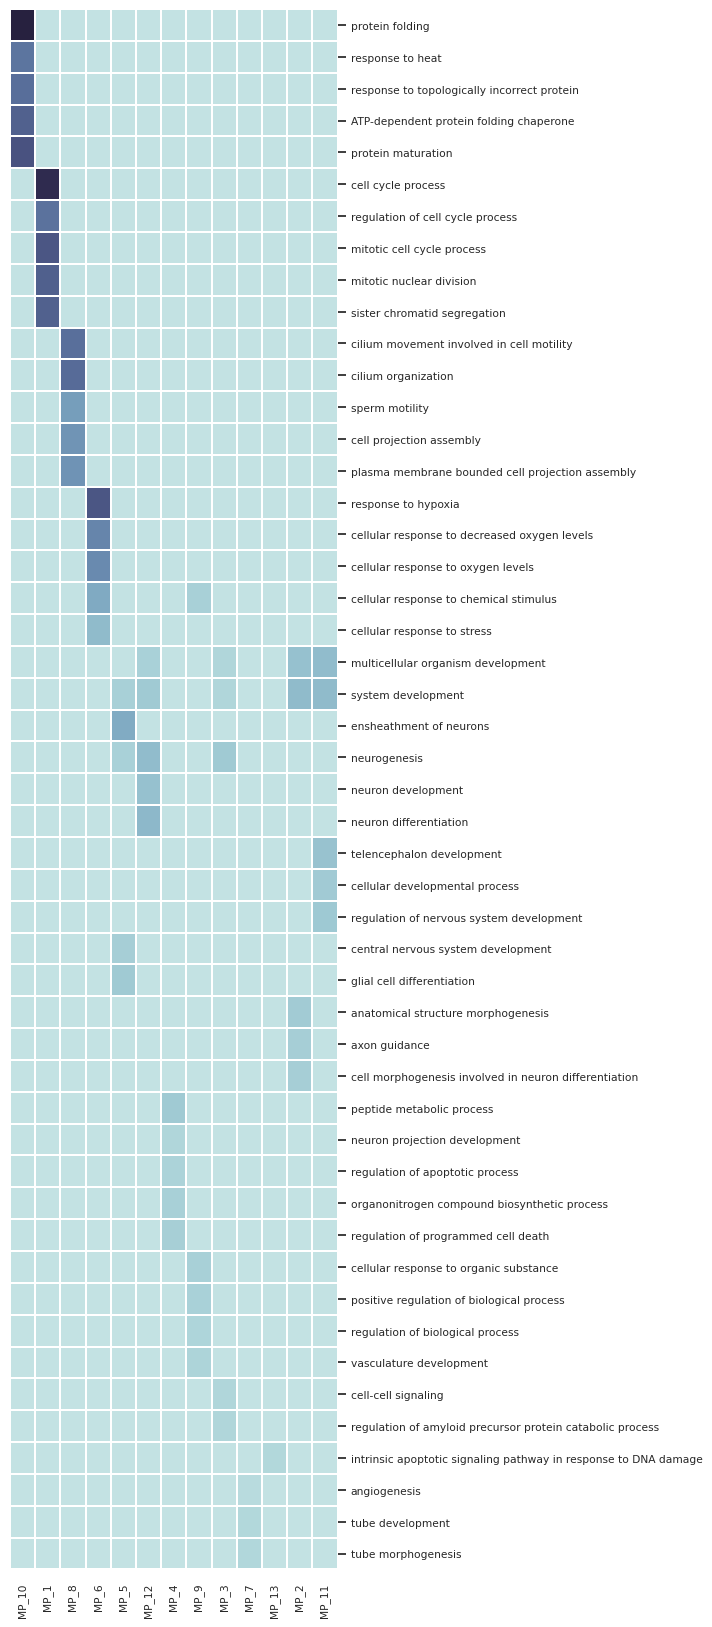

In [ ]:
sns.set(font_scale=0.70)
g = sns.clustermap( gm_df.T, col_cluster=True, figsize=(8,20), cmap=cmap, cbar_pos=(0.15, 0.825, 0.525, 0.012), 
                    cbar_kws={"orientation": "horizontal"}, linewidths=0.025)#, "ticks":-np.log10([1,0.05,0.005])})#, "ticklabels":["1.0", "0.05", "0.005"]})
g.ax_col_dendrogram.set_visible(False)
g.ax_row_dendrogram.set_visible(False)
plt.setp( g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90);
plt.setp( g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0);
g.cax.set_visible( False)

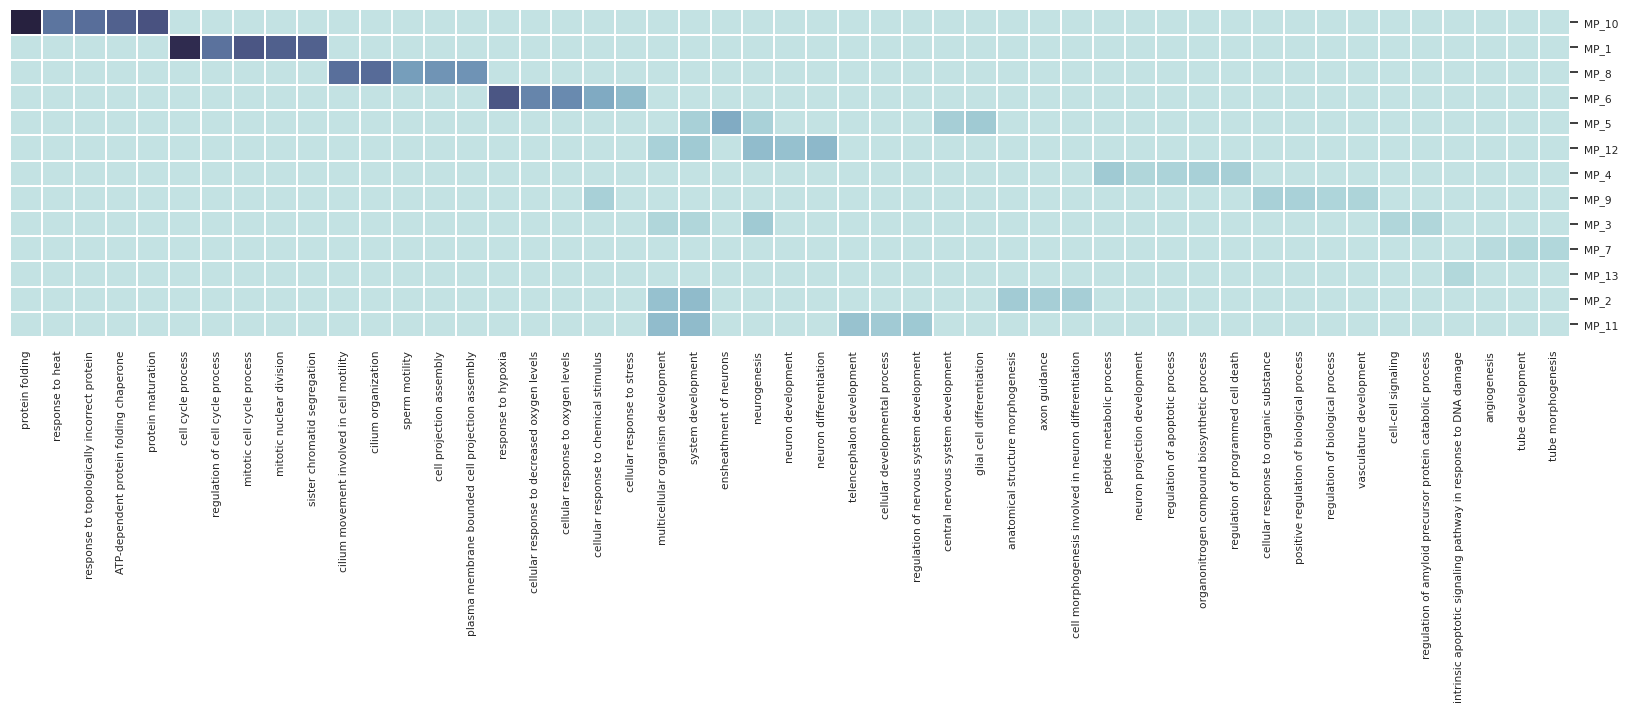

In [ ]:
sns.set(font_scale=0.70)
g = sns.clustermap( gm_df, col_cluster=True, figsize=(20,8), cmap=cmap, cbar_pos=(0.15, 0.825, 0.525, 0.012), 
                    cbar_kws={"orientation": "horizontal"}, linewidths=0.025)#, "ticks":-np.log10([1,0.05,0.005])})#, "ticklabels":["1.0", "0.05", "0.005"]})
g.ax_col_dendrogram.set_visible(False)
g.ax_row_dendrogram.set_visible(False)
plt.setp( g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90);
plt.setp( g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0);
g.cax.set_visible( False)
# plt.savefig( "/dd_userdata/usrdat03/userdata/cherring/data/cellranger_outputs/brain_maturation_RNA/hotspot_GOs-vs-modules.svg", format='svg')

In [ ]:
gm_df.to_csv( "../data/malignant_GOs-vs-modules_dataframe.csv")
in_df.to_csv( "../data/malignant_GOs-vs-modules_dataframe_intersect.csv")

## R

In [ ]:
library(ggplot2)
library(reshape2)
library(ggsci)
library(rcartocolor)
library(cba)
library(palettetown)
library(dplyr)

Loading required package: grid

Loading required package: proxy


Attaching package: ‘proxy’


The following objects are masked from ‘package:stats’:

    as.dist, dist


The following object is masked from ‘package:base’:

    as.matrix



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
dat <- read.csv("../data/malignant_GOs-vs-modules_dataframe.csv", 
                check.names = FALSE)
dat_inter <- read.csv("../data/malignant_GOs-vs-modules_dataframe_intersect.csv", 
                      check.names = FALSE)

In [ ]:
dat

,ATP-dependent protein folding chaperone,anatomical structure morphogenesis,angiogenesis,axon guidance,cell cycle process,cell morphogenesis involved in neuron differentiation,cell projection assembly,cell-cell signaling,cellular developmental process,⋯,response to heat,response to hypoxia,response to topologically incorrect protein,sister chromatid segregation,sperm motility,system development,telencephalon development,tube development,tube morphogenesis,vasculature development
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MP_1,0.00000,0.000000,0.000000,0.000000,29.70876,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,21.21762,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000
MP_2,0.00000,4.497202,0.000000,3.841063,0.00000,3.893847,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,7.229712,0.00000,0.000000,0.000000,0.00000
MP_3,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,2.499523,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,2.491655,0.00000,0.000000,0.000000,0.00000
MP_4,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000
MP_5,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,3.597567,0.00000,0.000000,0.000000,0.00000
MP_6,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,22.79853,0.0000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,0.00000
MP_7,0.00000,0.000000,1.421312,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,0.000000,0.00000,2.239859,2.365037,0.00000
MP_8,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,13.42889,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,12.06028,0.000000,0.00000,0.000000,0.000000,0.00000
MP_9,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,⋯,0.00000,0.00000,0.0000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000,2.79759


In [ ]:
dat_inter

,ATP-dependent protein folding chaperone,anatomical structure morphogenesis,angiogenesis,axon guidance,cell cycle process,cell morphogenesis involved in neuron differentiation,cell projection assembly,cell-cell signaling,cellular developmental process,⋯,response to heat,response to hypoxia,response to topologically incorrect protein,sister chromatid segregation,sperm motility,system development,telencephalon development,tube development,tube morphogenesis,vasculature development
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MP_1,0,0,0,0,36,0,0,0,0,⋯,0,0,0,19,0,0,0,0,0,0
MP_2,0,22,0,8,0,11,0,0,0,⋯,0,0,0,0,0,30,0,0,0,0
MP_3,0,0,0,0,0,0,0,15,0,⋯,0,0,0,0,0,23,0,0,0,0
MP_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
MP_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,26,0,0,0,0
MP_6,0,0,0,0,0,0,0,0,0,⋯,0,21,0,0,0,0,0,0,0,0
MP_7,0,0,8,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,12,11,0
MP_8,0,0,0,0,0,0,17,0,0,⋯,0,0,0,0,11,0,0,0,0,0
MP_9,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,11


In [ ]:
rownames(dat) <- dat[,1]
colnames(dat)[1] <- "modules"
rownames(dat_inter) <- dat_inter[,1]
colnames(dat_inter)[1] <- "modules"

In [ ]:
order_row <- c(1:13)

In [ ]:
hc <- hclust(dist(t(dat[order_row,-1])))
order_col <- order.optimal(dist(t(dat[order_row,-1])), hc$merge)

In [ ]:
dat <- melt(dat, id.vars="modules")
dat

modules,variable,value
<chr>,<fct>,<dbl>
MP_1,ATP-dependent protein folding chaperone,0.000000
MP_2,ATP-dependent protein folding chaperone,0.000000
MP_3,ATP-dependent protein folding chaperone,0.000000
MP_4,ATP-dependent protein folding chaperone,0.000000
MP_5,ATP-dependent protein folding chaperone,0.000000
MP_6,ATP-dependent protein folding chaperone,0.000000
MP_7,ATP-dependent protein folding chaperone,0.000000
MP_8,ATP-dependent protein folding chaperone,0.000000
MP_9,ATP-dependent protein folding chaperone,0.000000


In [ ]:
dat_inter <- melt(dat_inter, id.vars="modules")
dat_inter

modules,variable,value
<chr>,<fct>,<dbl>
MP_1,ATP-dependent protein folding chaperone,0
MP_2,ATP-dependent protein folding chaperone,0
MP_3,ATP-dependent protein folding chaperone,0
MP_4,ATP-dependent protein folding chaperone,0
MP_5,ATP-dependent protein folding chaperone,0
MP_6,ATP-dependent protein folding chaperone,0
MP_7,ATP-dependent protein folding chaperone,0
MP_8,ATP-dependent protein folding chaperone,0
MP_9,ATP-dependent protein folding chaperone,0


In [ ]:
colnames(dat) <- c("modules", "GO terms", "p-values")
dat$intersect <- dat_inter[,3]
dat[dat[,3]==0,3] <- NA
dat[dat[,4]==0,4] <- NA

order_modules <- c('MP_1',
'MP_2',
'MP_3',
'MP_4',
'MP_5',
'MP_6',
'MP_7',
'MP_8',
'MP_9',
'MP_10',
'MP_11',
'MP_12',
'MP_13')
dat$modules <- factor(dat$modules, levels=rev(order_modules))

order_go_terms <- names(order_col$order)[order_col$order]
dat$`GO terms` <- factor(dat$`GO terms`, levels=order_go_terms)


dat <- dat[!is.na(dat[,3]),]
dat <- dat[dat$`p-values`>log10(0.05)*-1,]

In [ ]:
dat

,modules,GO terms,p-values,intersect
,<fct>,<fct>,<dbl>,<dbl>
10,MP_10,ATP-dependent protein folding chaperone,21.219357,12
15,MP_2,anatomical structure morphogenesis,4.497202,22
33,MP_7,angiogenesis,1.421312,8
41,MP_2,axon guidance,3.841063,8
53,MP_1,cell cycle process,29.708757,36
67,MP_2,cell morphogenesis involved in neuron differentiation,3.893847,11
86,MP_8,cell projection assembly,13.428888,17
94,MP_3,cell-cell signaling,2.499523,15
115,MP_11,cellular developmental process,4.625933,28


In [ ]:
gg_final <- ggplot(dat, aes(y=modules, x=`GO terms`, 
    fill=`p-values`, size=intersect)) + 
    geom_point(colour="black", pch=21) + theme_light() +
    scale_fill_material("grey") + 
    scale_x_discrete(guide = guide_axis(angle = 90)) +
    scale_y_discrete(expand=expansion(mult = 0, add = 0.75)) +
    scale_size(range = c(0, 5)) +
    theme(plot.margin=unit(c(5.5, 40, 5.5, 5.5), "points"),
          axis.text.x = element_text(size=7)) 

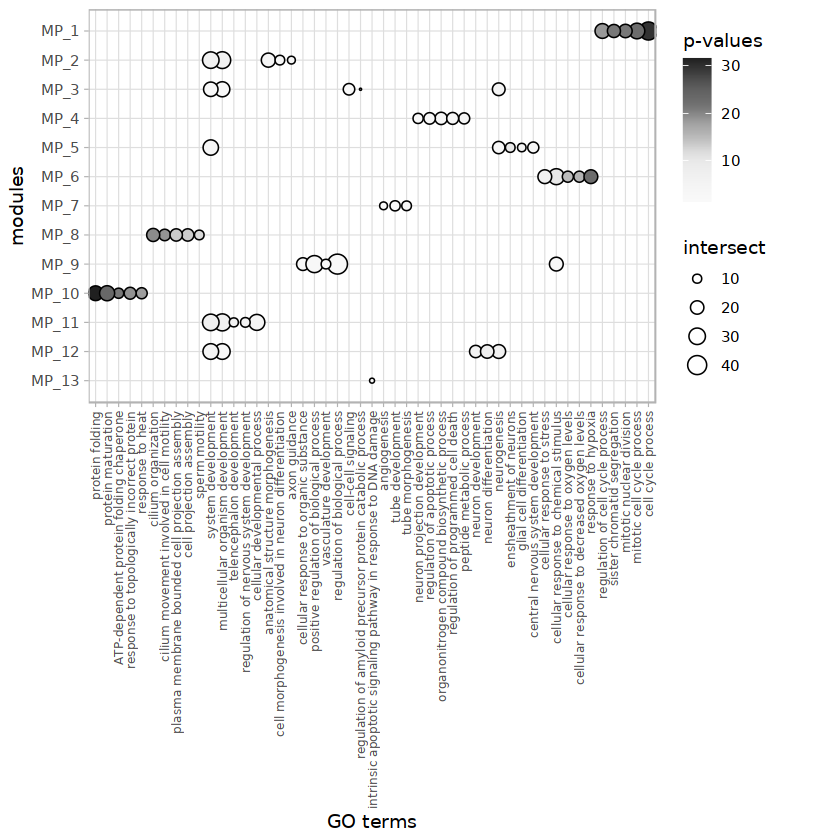

In [ ]:
gg_final

In [ ]:
ggsave(gg_final, file="../figures/malignant_go_terms.pdf", height=5.5, width = 9)